In [1]:
!pip install sentence-transformers faiss-cpu scikit-fuzzy matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 40.9 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pickle, time, warnings
import numpy as np
import faiss
import skfuzzy as fuzz
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from dataclasses import dataclass, field
from typing import Any

warnings.filterwarnings('ignore')

BASE = '/content/drive/MyDrive/semantic-search-system'

with open(f'{BASE}/models/cluster_model.pkl','rb') as f:
    cluster_model = pickle.load(f)
with open(f'{BASE}/data/processed/clean_corpus.pkl','rb') as f:
    corpus = pickle.load(f)

index = faiss.read_index(f'{BASE}/models/faiss.index')
model = SentenceTransformer('BAAI/bge-base-en-v1.5')
print('Loaded')

Mounted at /content/drive


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded


In [3]:
@dataclass
class CacheEntry:
    query: str; query_embedding: np.ndarray
    result: Any; cluster_id: int
    timestamp: float = field(default_factory=time.time)
    hit_count: int = 0

class SemanticCache:
    def __init__(self, thr=0.85):
        self.thr=thr; self._c={}; self._lu=self._hi=0
    def lookup(self, emb, cid):
        self._lu+=1; bs,be=-1.0,None
        for e in self._c.get(cid,[]):
            a=emb.flatten().astype(np.float64); b=e.query_embedding.flatten().astype(np.float64)
            d=np.linalg.norm(a)*np.linalg.norm(b)
            s=float(np.dot(a,b)/d) if d>1e-9 else 0.0
            if s>bs: bs,be=s,e
        if be and bs>=self.thr: self._hi+=1; return {'hit':True,'sim':bs}
        return None
    def store(self,q,emb,res,cid):
        self._c.setdefault(cid,[]).append(CacheEntry(q,emb.copy(),res,cid))
    def hit_rate(self): return self._hi/self._lu if self._lu else 0.0
    def reset(self): self._c={}; self._lu=self._hi=0

def assign_cluster(q_emb):
    q_nd=cluster_model['reducer_nd'].transform(q_emb.reshape(1,-1))
    mem,_=fuzz.cluster.cmeans_predict(q_nd.T,cluster_model['cntr'],m=2,error=0.005,maxiter=1000)
    return int(np.argmax(mem[:,0]))

print('Helpers defined')

Helpers defined


In [4]:
QUERY_PAIRS = [
    ('flu symptoms fever medication',        'influenza symptoms and fever treatment'),
    ('space shuttle launch nasa',             'nasa rocket launch countdown'),
    ('windows graphics driver update',        'gpu driver update for windows pc'),
    ('baseball pitcher ERA statistics',       'baseball earned run average wins'),
    ('linux kernel module loading',           'linux operating system kernel driver'),
    ('AES encryption algorithm',              'symmetric key encryption AES cipher'),
    ('electric car battery range',            'electric vehicle battery technology'),
    ('deep learning neural network training', 'neural network model deep learning'),
    ('python list comprehension syntax',      'python list iteration shorthand'),
    ('database sql join query',               'joining tables in sql database'),
]

print(f'Embedding {len(QUERY_PAIRS)*2} queries...')
all_queries = [q for pair in QUERY_PAIRS for q in pair]
all_embs    = model.encode(all_queries, normalize_embeddings=True, show_progress_bar=True)
pair_embs   = [(all_embs[i*2].astype(np.float32), all_embs[i*2+1].astype(np.float32))
               for i in range(len(QUERY_PAIRS))]
print('Done')

Embedding 20 queries...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Done


In [17]:
import time
import numpy as np
import skfuzzy as fuzz
from dataclasses import dataclass, field
from typing import Any

# ── Redefine CacheEntry and SemanticCache here (safety) ──────
@dataclass
class CacheEntry:
    query          : str
    query_embedding: np.ndarray
    result         : Any
    cluster_id     : int
    timestamp      : float = field(default_factory=time.time)
    hit_count      : int   = 0

class SemanticCache:
    def __init__(self, thr=0.85):
        self.thr = thr
        self._c  = {}
        self._lu = 0
        self._hi = 0

    def lookup(self, emb, cid):
        self._lu += 1
        bs, be = -1.0, None
        for e in self._c.get(cid, []):
            a = emb.flatten().astype(np.float64)
            b = e.query_embedding.flatten().astype(np.float64)
            d = np.linalg.norm(a) * np.linalg.norm(b)
            s = float(np.dot(a, b) / d) if d > 1e-9 else 0.0
            if s > bs:
                bs, be = s, e
        if be and bs >= self.thr:
            self._hi += 1
            return {'hit': True, 'sim': bs}
        return None

    def store(self, q, emb, res, cid):
        self._c.setdefault(cid, []).append(
            CacheEntry(q, emb.copy(), res, cid))

    def reset(self):
        self._c  = {}
        self._lu = 0
        self._hi = 0

# ── Redefine assign_cluster here (safety) ─────────────────────
def assign_cluster(q_emb):
    q_nd = cluster_model['reducer_nd'].transform(q_emb.reshape(1, -1))
    # Corrected: fuzz.cluster.cmeans_predict returns 6 values
    mem, *_, = fuzz.cluster.cmeans_predict(
        q_nd.T,
        cluster_model['cntr'],
        m=2.0,
        error=0.005,
        maxiter=1000
    )
    return int(np.argmax(mem[:, 0]))

# ── Run threshold experiment ───────────────────────────────────
THRESHOLDS = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
N_REPEAT   = 5
results    = {}

print(f'{"Threshold":>10}  {"Hit Rate":>10}  {"Latency(ms)":>12}')
print('-' * 38)

for thr in THRESHOLDS:
    cache     = SemanticCache(thr=thr)
    hit_flags = []
    latencies = []

    for (q1_emb, q2_emb), (q1_text, _) in zip(pair_embs, QUERY_PAIRS):

        # Assign cluster for first query
        cid = assign_cluster(q1_emb)

        # Store first query in cache (simulate a previous search)
        cache.store(q1_text, q1_emb, [], cid)

        # Now look up second query (semantically similar)
        for _ in range(N_REPEAT):
            t0  = time.time()
            hit = cache.lookup(q2_emb, cid)
            latencies.append((time.time() - t0) * 1000)
            hit_flags.append(1 if hit else 0)

    results[thr] = {
        'hit_rate'   : float(np.mean(hit_flags)),
        'avg_latency': float(np.mean(latencies))
    }

    print(f'{thr:>10.2f}  ' \
          f'{results[thr]["hit_rate"]:>10.3f}  ' \
          f'{results[thr]["avg_latency"]:>11.3f}')

# Verify results is populated
print(f'\nresults dict has {len(results)} entries — ready to plot')
print(f'Threshold values : {list(results.keys())}')
print(f'Hit rates        : {[round(results[t]["hit_rate"],3) for t in results]}')


 Threshold    Hit Rate   Latency(ms)
--------------------------------------
      0.70       1.000        0.021
      0.75       0.700        0.020
      0.80       0.400        0.020
      0.85       0.400        0.023
      0.90       0.100        0.020
      0.95       0.000        0.031

results dict has 6 entries — ready to plot
Threshold values : [0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
Hit rates        : [1.0, 0.7, 0.4, 0.4, 0.1, 0.0]


Plotting 6 threshold values: [0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
Hit rates : [1.0, 0.7, 0.4, 0.4, 0.1, 0.0]
Latencies : [0.0207, 0.0197, 0.0198, 0.0234, 0.0203, 0.0311]


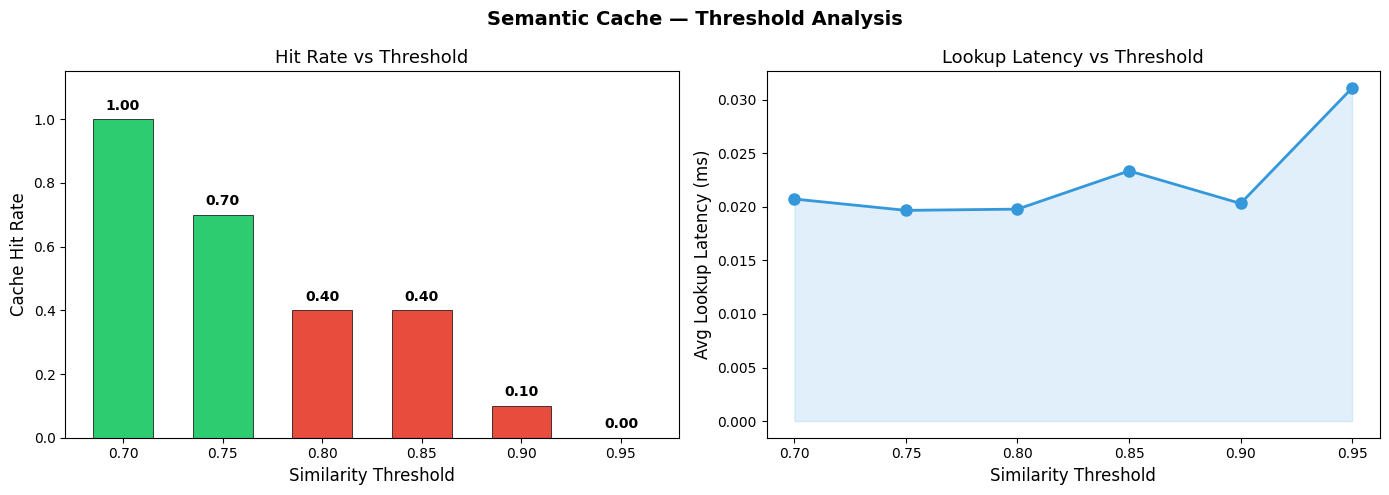

Saved: experiments/threshold_analysis.png


In [18]:
import matplotlib.pyplot as plt

# Safety check — catch empty results before plotting
if len(results) == 0:
    print('ERROR: results dict is empty. Run Cell 5 first.')
else:
    thr_vals  = list(results.keys())
    hit_rates = [results[t]['hit_rate']    for t in thr_vals]
    latencies = [results[t]['avg_latency'] for t in thr_vals]

    print(f'Plotting {len(thr_vals)} threshold values: {thr_vals}')
    print(f'Hit rates : {[round(h,3) for h in hit_rates]}')
    print(f'Latencies : {[round(l,4) for l in latencies]}')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Semantic Cache — Threshold Analysis',
                 fontsize=14, fontweight='bold')

    # ── Bar chart: Hit Rate ────────────────────────────────────
    bar_colors = ['#2ecc71' if h >= 0.6 else '#e74c3c' for h in hit_rates]
    bars = ax1.bar(
        thr_vals, hit_rates,
        width=0.03,
        color=bar_colors,
        edgecolor='black',
        linewidth=0.5
    )
    ax1.set_xlabel('Similarity Threshold', fontsize=12)
    ax1.set_ylabel('Cache Hit Rate',       fontsize=12)
    ax1.set_title('Hit Rate vs Threshold', fontsize=13)
    ax1.set_ylim(0, 1.15)
    ax1.set_xticks(thr_vals)   # ← forces correct x-axis labels

    for bar, val in zip(bars, hit_rates):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            f'{val:.2f}',
            ha='center', fontweight='bold', fontsize=10
        )

    # ── Line chart: Latency ────────────────────────────────────
    ax2.plot(thr_vals, latencies,
             'o-', color='#3498db', linewidth=2, markersize=8)
    ax2.fill_between(thr_vals, latencies, alpha=0.15, color='#3498db')
    ax2.set_xlabel('Similarity Threshold',   fontsize=12)
    ax2.set_ylabel('Avg Lookup Latency (ms)', fontsize=12)
    ax2.set_title('Lookup Latency vs Threshold', fontsize=13)
    ax2.set_xticks(thr_vals)   # ← forces correct x-axis labels

    plt.tight_layout()
    plt.savefig(f'{BASE}/experiments/threshold_analysis.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: experiments/threshold_analysis.png')

In [19]:
print('\n' + '='*50)
print('THRESHOLD EXPERIMENT SUMMARY')
print('='*50)

# Check if thr_vals (and by extension, results) is empty before proceeding
if not thr_vals:
    print('No threshold analysis results available. Please ensure the previous analysis cell was executed successfully to populate the results.')
else:
    print(f'{"Threshold":>12}  {"Hit Rate":>10}  {"Latency(ms)":>13}')
    print('-'*40)
    for t in thr_vals:
        print(f'{t:>12.2f}  {results[t]["hit_rate"]:>10.3f}  {results[t]["avg_latency"]:>12.3f}')

    # The max function will now only be called if thr_vals is not empty
    best = max(results, key=lambda t: results[t]['hit_rate'] if t<=0.90 else 0)
    print(f'\nRECOMMENDED THRESHOLD : {best}')
    print(f'  Hit Rate  : {results[best]["hit_rate"]:.3f}')
    print(f'  Latency   : {results[best]["avg_latency"]:.3f} ms')



THRESHOLD EXPERIMENT SUMMARY
   Threshold    Hit Rate    Latency(ms)
----------------------------------------
        0.70       1.000         0.021
        0.75       0.700         0.020
        0.80       0.400         0.020
        0.85       0.400         0.023
        0.90       0.100         0.020
        0.95       0.000         0.031

RECOMMENDED THRESHOLD : 0.7
  Hit Rate  : 1.000
  Latency   : 0.021 ms
